In [2]:
# 1. Binary classification 실습
# 예제 데이터 : breast cancer data set
# 목표 :
# - 이진 분류 모델 핛브
# - 학습 결과 저장
# - 저장된 모델 / 스케일러 / 학습 이력 불러오기
# - 신규 데이터 예측
# - 학습 결과 및 예측결과 시각화

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score,auc
from sklearn.datasets import load_digits, load_breast_cancer
import joblib # 파이썬 객체 저장을 위한 joblib
import tensorflow as tf

# keras 모델 저장 및 로드 기능 사용하기 위한 필요 모듈
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten
from tensorflow.keras.callbacks import EarlyStopping

# 앞으로 딥러닝 할 때는 학습결과 파일을 관리를 잘 해야함.

np.random.seed(42)
tf.random.set_seed(42)

In [16]:
# ======================================
# 1 데이터 읽어오기 (유방암 데이터셋)
# ======================================

data = load_breast_cancer()
X = data.data
y = data.target # 타겟 레이블 y 데이터

feature_names = data.feature_names # 특성 이름
df = pd.DataFrame(X, columns=feature_names) # 데이터 확인을 데이터 프레임으로 변환

df['target'] = y # 타겟 컬럼을 추가
print('전체 데이터 shape : ', df.shape)


전체 데이터 shape :  (569, 31)


In [17]:
df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


In [21]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,

In [18]:
# ======================================
# 2. train test split
# ======================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [19]:
X_train

array([[1.032e+01, 1.635e+01, 6.531e+01, ..., 2.381e-02, 2.681e-01,
        7.399e-02],
       [2.018e+01, 1.954e+01, 1.338e+02, ..., 2.173e-01, 3.032e-01,
        8.075e-02],
       [1.066e+01, 1.515e+01, 6.749e+01, ..., 0.000e+00, 2.710e-01,
        6.164e-02],
       ...,
       [1.546e+01, 2.395e+01, 1.038e+02, ..., 2.163e-01, 3.013e-01,
        1.067e-01],
       [1.705e+01, 1.908e+01, 1.134e+02, ..., 2.543e-01, 3.109e-01,
        9.061e-02],
       [1.088e+01, 1.562e+01, 7.041e+01, ..., 7.966e-02, 2.581e-01,
        1.080e-01]], shape=(455, 30))

In [22]:
# ======================================
# 3. 스케일링
# ======================================

# 값들의 평균 크기가 많이 차이나면.. 해줘야 함.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) # 학습 데이터 기준으로 평균과 표준편차를 학습하고 반환
X_test_scaled = scaler.transform(X_test) # 테스트 데이터는 학습 데이터 기준으로 반환

In [23]:
# ======================================
# 4. 모델 정의
# ======================================
model = Sequential() # 모델은 순차형 신경망
model.add(Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)))
model.add(Dropout(0.2)) # 과적합 방지, 전체 64개 뉴런 중에서 20%는 스킵하라는 것
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1, activation='sigmoid')) #이진분류기 때문에 둘 중에 하나 출력하는 것이고, 출력은 하나.
model.summary() #모델 학습할 때 구조를 출력해 보여줌.

D:\anaconda3\envs\analyzer\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
# ======================================
# 5. 모델 컴파일
# ======================================
# 손실함수는 binary cross_entropy, 평가지표는 accuracy 사용

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 조기 종료 콜백 정의
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [29]:
# ======================================
# 6. 모델 학습
# ======================================

# 모델을 학습하고, 히스토리 객체에 학습과정을 저장할 것.
history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.5659 - loss: 0.6131 - val_accuracy: 0.9231 - val_loss: 0.4383
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9231 - loss: 0.4163 - val_accuracy: 0.9451 - val_loss: 0.3112
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9368 - loss: 0.2999 - val_accuracy: 0.9670 - val_loss: 0.2265
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9396 - loss: 0.2211 - val_accuracy: 0.9670 - val_loss: 0.1709
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9560 - loss: 0.1701 - val_accuracy: 0.9670 - val_loss: 0.1368
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9533 - loss: 0.1440 - val_accuracy: 0.9670 - val_loss: 0.1166
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9615 - loss: 0.1275 - val_accuracy: 0.9670 - val_loss: 0.1027
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9588 - loss: 0.1082 - val_accuracy: 0.9670 -

In [33]:
# ======================================
# 7. 모델 평가
# ======================================

# 테스트 데이터에 대해 손실과 정확도 평가
test_loss, test_acc = model.evaluate(X_test_scaled, y_test, verbose=0)

print('테스트 손실 : ', test_loss)
print('테스트 정확도 : ', test_acc)

# 예측 확률
y_prob = model.predict(X_test_scaled)

# 확률을 0 또는 1 클래스로 변환
y_pred = (y_prob >= 0.5).astype(int).flatten()

# 정확도 계산
acc = accuracy_score(y_test, y_pred)

# confusion matrix 계산 (분류모델이니까)
cm = confusion_matrix(y_test, y_pred)

# 분류 리포트 출력
print("정확도 : ", acc)
print()
print("confusion matrix : \n", cm)
print()
print('분류 리포트 : \n', classification_report(y_test, y_pred))

테스트 손실 :  0.1042073667049408
테스트 정확도 :  0.9649122953414917
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
정확도 :  0.9649122807017544

confusion matrix : 
 [[41  1]
 [ 3 69]]

분류 리포트 : 
               precision    recall  f1-score   support

           0       0.93      0.98      0.95        42
           1       0.99      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.97      0.96       114
weighted avg       0.97      0.96      0.97       114



In [39]:
# ======================================
# 8. 학습 결과 저장
# ======================================

# 학습 결과 배포 이거를 계속 업데이트 하면서 배포하는 식.
DL_DATA_PATH = "./data/DL/"
model.save(DL_DATA_PATH + 'Binary_Classification.h5') # .h5 로 저장했을 때 잘 되지 않으면 .keras 형식 파일로 저장 가능.

# 스케일러를 파일로 저장
joblib.dump(scaler, DL_DATA_PATH + 'Binary_Classification_scaler.pkl')

# 학습 이력을 df 로 변환
history_df = pd.DataFrame(history.history)

# 학습이력을 csv 파일로 저장
history_df.to_csv(DL_DATA_PATH+"Binary_Classification_history.csv",index=False)

# 저장 완료 메세지 출력
print("이진분류 모델, 스케일러, 학습이력 저장 완료")

이진분류 모델, 스케일러, 학습이력 저장 완료


In [43]:
# ======================================
# 9. 저장된 결과 읽어오기. (추론 쪽에서 하는 역할)
# ======================================
# 저장된 모델 다시 불러오기.
loaded_model = tf.keras.models.load_model(DL_DATA_PATH + 'Binary_Classification.h5')

# 저장된 스케일러를 다시 불러오기
loaded_scaler = joblib.load(DL_DATA_PATH + 'Binary_Classification_scaler.pkl')

In [47]:
# ======================================
# 10. 신규 데이터 예측
# ======================================

# 학습하지 않은 테스트데이터로 중 첫 5개를 신규 데이터로 예측 수행
new_data = X_test[:5]

# 학습데이터를 스케일링 처리 해줬기 때문에 테스트 데이터도 스케일링 해줘야 함.
new_data_scaled = load_scaler.transform(new_data)

# 신규데이터의 예측확률 계산.
new_prob = loaded_model.predict(new_data_scaled)

# 예측 확률값을 0/1로 변환
new_pred = (new_prob >= 0.5).astype(int).flatten()

#결과 출력
for i in range(len(new_data)):
    print(f"{i+1}번 샘플 - 예측확률 : {new_prob[i][0]:.4f}, 예측 클래스 {new_pred[i]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1번 샘플 - 예측확률 : 0.0000, 예측 클래스 0
2번 샘플 - 예측확률 : 1.0000, 예측 클래스 1
3번 샘플 - 예측확률 : 0.0000, 예측 클래스 0
4번 샘플 - 예측확률 : 0.1055, 예측 클래스 0
5번 샘플 - 예측확률 : 0.0000, 예측 클래스 0


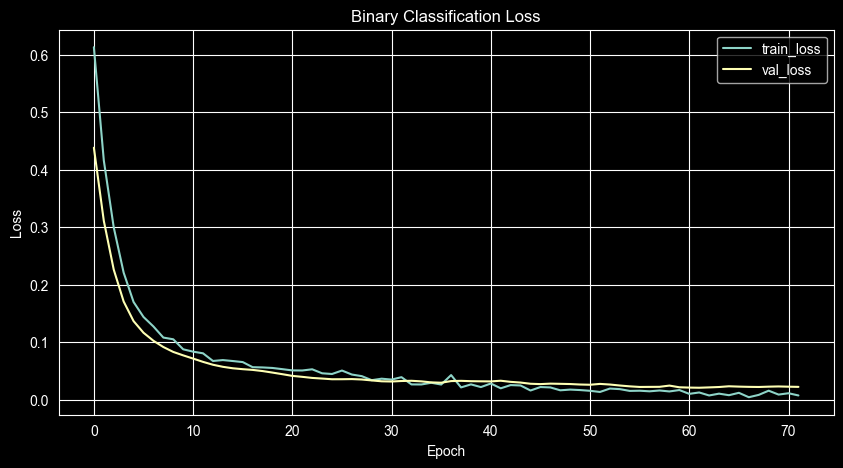

In [48]:
# ======================================
# 11. 시각화 결과 확인
# ======================================

# 학습결과 시각화
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'],label='train_loss')
plt.plot(history.history['val_loss'],label='val_loss')
plt.title("Binary Classification Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

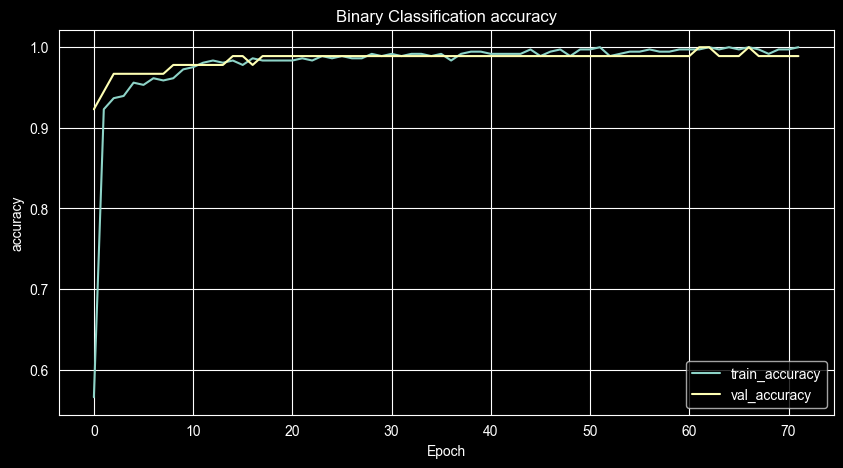

In [49]:
# 학습 정확도 시각화
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'],label='train_accuracy')
plt.plot(history.history['val_accuracy'],label='val_accuracy')
plt.title("Binary Classification accuracy")
plt.xlabel("Epoch")
plt.ylabel("accuracy")
plt.legend()
plt.grid(True)
plt.show()

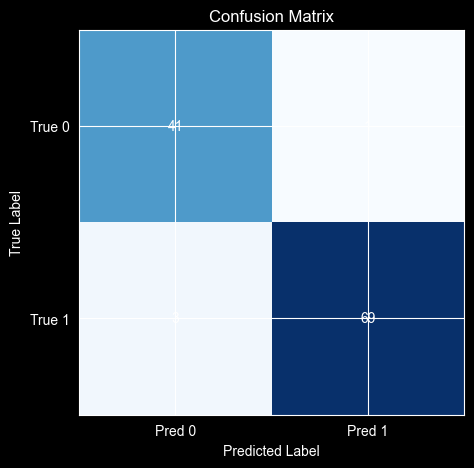

In [51]:
# confusion matrix 시각화
plt.figure(figsize=(10,5))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")

# x축과 y축 눈금 설정
plt.xticks([0,1], ['Pred 0', 'Pred 1'])
plt.yticks([0,1], ['True 0', 'True 1'])

# CM 내부에 숫자 표시
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j,i,cm[i,j], ha='center', va='center')

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

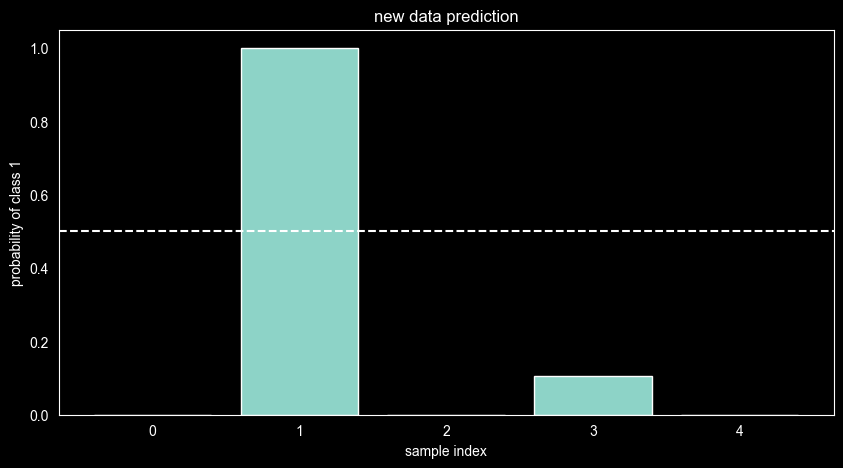

In [53]:
# 신규 데이터 예측 결과 시각화
# 신규데이터 예측 확률을 1차원 벡터 데이터로 만들어주고
new_prob_flat = new_prob.flatten()
plt.figure(figsize=(10,5))
plt.bar(range(len(new_prob_flat)), new_prob_flat)

# 기준선 0.5로 표시
plt.axhline(0.5, linestyle='--')
plt.title("new data prediction")
plt.xlabel("sample index")
plt.ylabel("probability of class 1")
plt.grid()
plt.show()

서비스 할 때, 지금 그래프처럼, AI 진단 결과 1일 확률이 (각 어떤 클래스일 확률) 이 n%로 가장 높습니다.

In [ ]:
# ======================================
# 1 데이터 읽어오기 (유방암 데이터셋)
# ======================================

In [ ]:
# ======================================
# 1 데이터 읽어오기 (유방암 데이터셋)
# ======================================